# Live analysis — daily charts from Kaggle agent logs

Parses `[exec] … PASS` and `[snap] …` lines from `kaggle competitions logs` JSON.

**Note:** Older logs without `[snap]` lines only populate the PASS panel. Re-run after a submission that includes the snap logger.

In [3]:
filepath = "submissions/260812_1/92233598-0.json"

In [4]:
import json
import re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "agent").exists():
    ROOT = ROOT.parent

LOG_PATH = ROOT / filepath
PASS_RE = re.compile(r"\[exec\] d=(\d+) h=(\d+) (farmer|hand\d+) PASS")
SNAP_RE = re.compile(
    r"\[snap\] d=(\d+) h=(\d+) money=(\d+) filled=(\d+) empty=(\d+) weeds=(\d+) "
    r"owned=(\d+) shops=(\d+) demand=(\d+)(?: (.+))?"
)


def load_stdout_lines(path: Path) -> list[str]:
    with open(path, encoding="utf-8") as f:
        steps = json.load(f)
    lines: list[str] = []
    for step in steps:
        if isinstance(step, list):
            for item in step:
                if isinstance(item, dict) and item.get("stdout"):
                    lines.extend(item["stdout"].splitlines())
        elif isinstance(step, dict) and step.get("stdout"):
            lines.extend(step["stdout"].splitlines())
    return lines


def parse_passes(lines: list[str]) -> pd.DataFrame:
    counts: dict[tuple[int, str], int] = defaultdict(int)
    for line in lines:
        m = PASS_RE.search(line)
        if m:
            counts[(int(m.group(1)), m.group(3))] += 1
    if not counts:
        return pd.DataFrame(columns=["day", "worker", "passes"])
    rows = [
        {"day": day, "worker": worker, "passes": n}
        for (day, worker), n in sorted(counts.items())
    ]
    return pd.DataFrame(rows)


def parse_snaps(lines: list[str]) -> pd.DataFrame:
    rows: list[dict] = []
    for line in lines:
        m = SNAP_RE.search(line)
        if not m:
            continue
        row = {
            "day": int(m.group(1)),
            "hour": int(m.group(2)),
            "money": int(m.group(3)),
            "filled": int(m.group(4)),
            "empty": int(m.group(5)),
            "weeds": int(m.group(6)),
            "owned": int(m.group(7)),
            "shops": int(m.group(8)),
            "demand": int(m.group(9)),
        }
        tail = m.group(10) or ""
        for part in tail.split():
            if "=" in part:
                key, val = part.split("=", 1)
                row[key] = int(val)
        rows.append(row)
    return pd.DataFrame(rows)


lines = load_stdout_lines(LOG_PATH)
passes_df = parse_passes(lines)
snaps_df = parse_snaps(lines)
print(f"log: {LOG_PATH.name}  lines={len(lines)}  passes={len(passes_df)}  snaps={len(snaps_df)}")

log: 92233598-0.json  lines=2899  passes=114  snaps=0


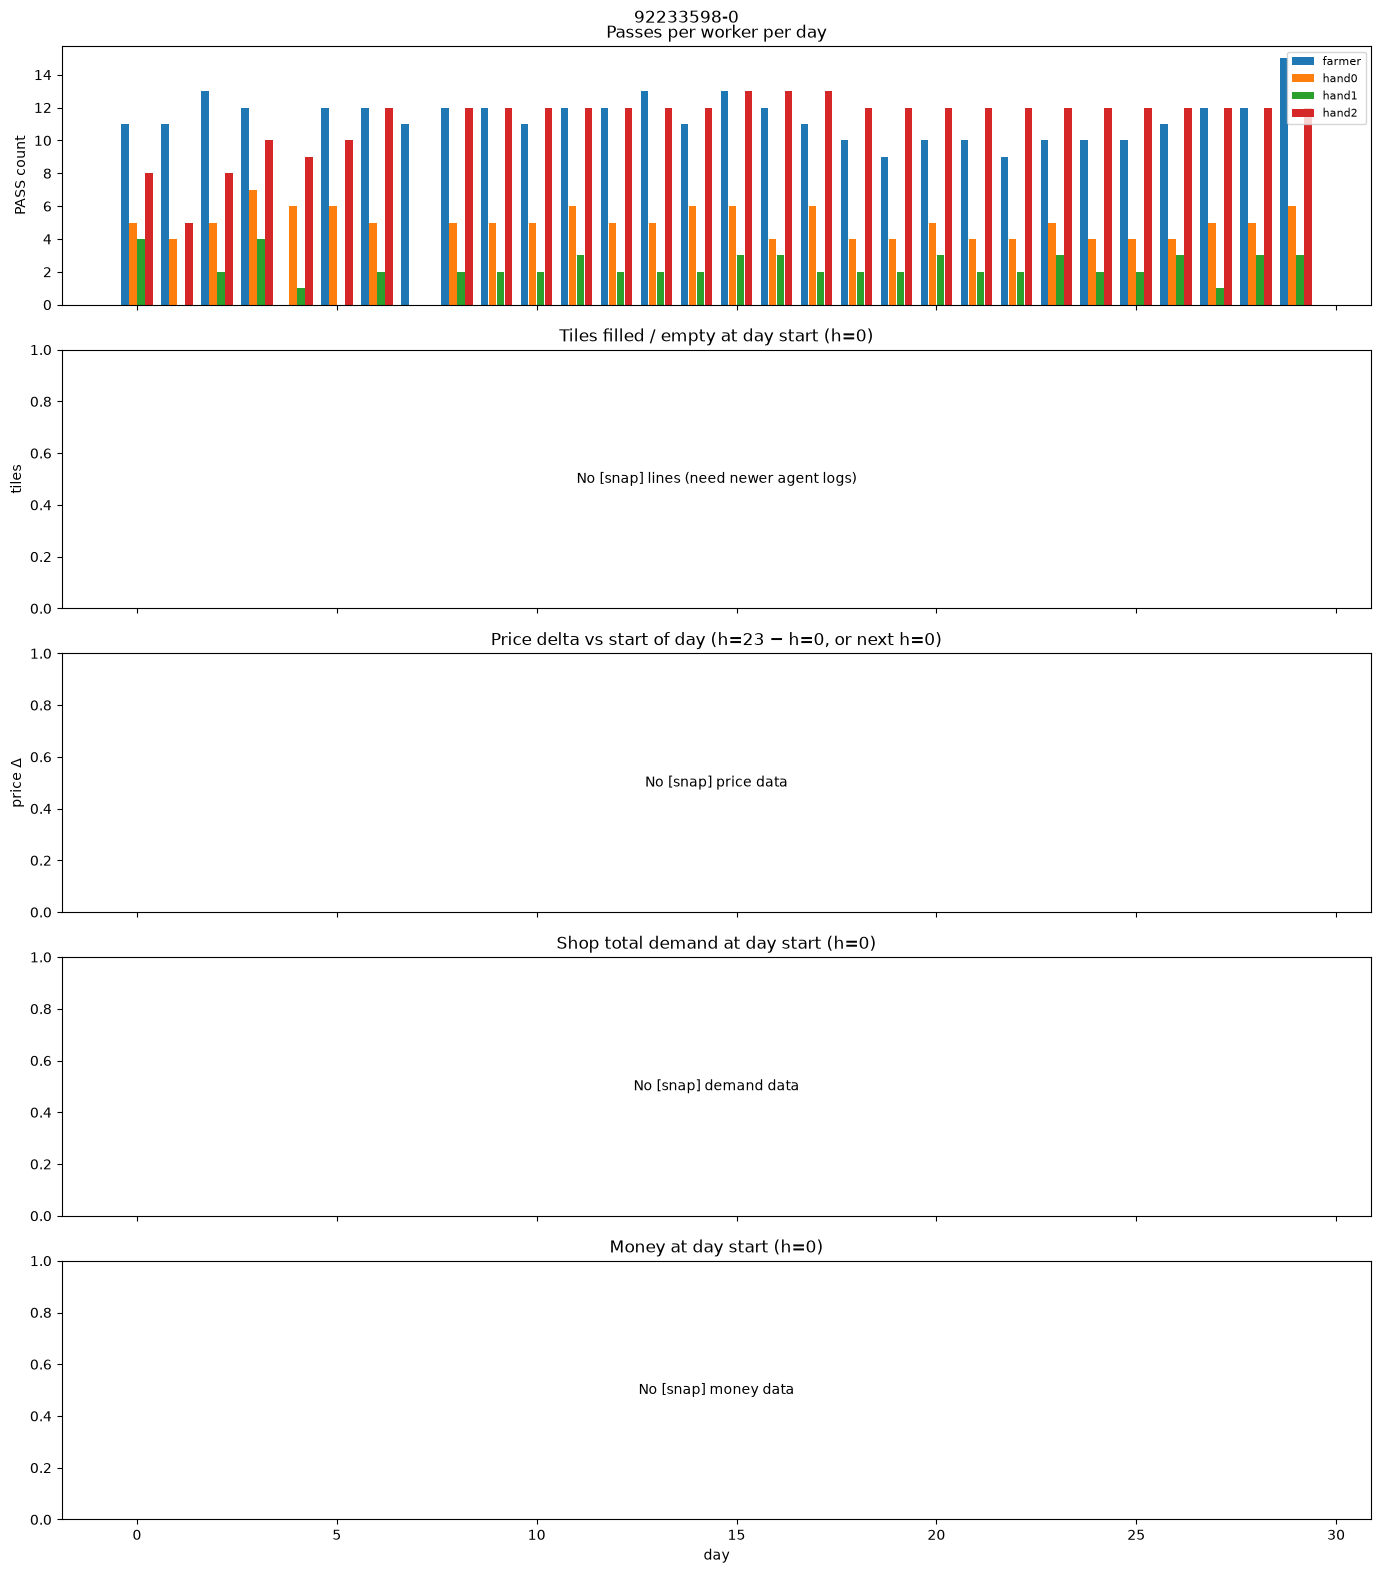

In [5]:
DAYS = list(range(30))


def series_by_day(
    df: pd.DataFrame,
    value_col: str,
    day_col: str = "day",
    days: list[int] | None = None,
    fill: float | None = 0,
) -> pd.Series:
    """Reindex one numeric column onto the full day range; missing days get fill."""
    days = days if days is not None else DAYS
    if df.empty or value_col not in df.columns:
        val = fill if fill is not None else float("nan")
        return pd.Series(val, index=days, dtype=float)
    s = df.set_index(day_col)[value_col].astype(float)
    if fill is not None:
        return s.reindex(days, fill_value=fill)
    return s.reindex(days)


def price_delta_by_day(snaps: pd.DataFrame) -> pd.DataFrame:
    if snaps.empty:
        return pd.DataFrame()
    price_cols = [
        c
        for c in snaps.columns
        if c
        not in {
            "day",
            "hour",
            "money",
            "filled",
            "empty",
            "weeds",
            "owned",
            "shops",
            "demand",
        }
    ]
    if not price_cols:
        return pd.DataFrame()
    start = snaps[snaps["hour"] == 0].set_index("day")
    end = snaps[snaps["hour"] == 23].set_index("day")
    rows = []
    for day in DAYS:
        if day not in start.index:
            continue
        s = start.loc[day]
        if day in end.index:
            e = end.loc[day]
        elif day + 1 in start.index:
            e = start.loc[day + 1]
        else:
            continue
        for col in price_cols:
            if col in s and col in e:
                rows.append(
                    {
                        "day": day,
                        "product": col,
                        "delta": int(e[col]) - int(s[col]),
                    }
                )
    return pd.DataFrame(rows)


def plot_live_analysis(passes: pd.DataFrame, snaps: pd.DataFrame) -> None:
    fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)
    fig.suptitle(LOG_PATH.stem, fontsize=12)

    ax0 = axes[0]
    if passes.empty:
        ax0.text(0.5, 0.5, "No PASS lines", ha="center", va="center", transform=ax0.transAxes)
    else:
        workers = sorted(passes["worker"].unique(), key=lambda w: (w != "farmer", w))
        width = 0.8 / max(len(workers), 1)
        for i, worker in enumerate(workers):
            sub = passes[passes["worker"] == worker]
            counts = series_by_day(sub, "passes", fill=0)
            offset = (i - (len(workers) - 1) / 2) * width
            ax0.bar([d + offset for d in DAYS], counts.values, width=width * 0.95, label=worker)
        ax0.legend(loc="upper right", fontsize=8)
    ax0.set_ylabel("PASS count")
    ax0.set_title("Passes per worker per day")

    ax1 = axes[1]
    day_snaps = snaps[snaps["hour"] == 0] if not snaps.empty else pd.DataFrame()
    if day_snaps.empty:
        ax1.text(
            0.5,
            0.5,
            "No [snap] lines (need newer agent logs)",
            ha="center",
            va="center",
            transform=ax1.transAxes,
        )
    else:
        filled = series_by_day(day_snaps, "filled", fill=float("nan"))
        empty = series_by_day(day_snaps, "empty", fill=float("nan"))
        ax1.plot(DAYS, filled.values, marker="o", label="filled")
        ax1.plot(DAYS, empty.values, marker="o", label="empty (holes)")
        ax1.legend(loc="upper left", fontsize=8)
    ax1.set_ylabel("tiles")
    ax1.set_title("Tiles filled / empty at day start (h=0)")

    ax2 = axes[2]
    price_df = price_delta_by_day(snaps)
    if price_df.empty:
        ax2.text(
            0.5,
            0.5,
            "No [snap] price data",
            ha="center",
            va="center",
            transform=ax2.transAxes,
        )
    else:
        for product in sorted(price_df["product"].unique()):
            sub = price_df[price_df["product"] == product]
            deltas = series_by_day(sub, "delta", fill=float("nan"))
            ax2.plot(DAYS, deltas.values, marker=".", label=product, alpha=0.85)
        ax2.axhline(0, color="gray", linewidth=0.8)
        ax2.legend(loc="upper right", fontsize=7, ncol=3)
    ax2.set_ylabel("price Δ")
    ax2.set_title("Price delta vs start of day (h=23 − h=0, or next h=0)")

    ax3 = axes[3]
    if day_snaps.empty:
        ax3.text(
            0.5,
            0.5,
            "No [snap] demand data",
            ha="center",
            va="center",
            transform=ax3.transAxes,
        )
    else:
        demand = series_by_day(day_snaps, "demand", fill=float("nan"))
        ax3.bar(DAYS, demand.values, color="steelblue")
        ax3.set_ylabel("demand units")
    ax3.set_title("Shop total demand at day start (h=0)")

    ax4 = axes[4]
    if day_snaps.empty:
        ax4.text(
            0.5,
            0.5,
            "No [snap] money data",
            ha="center",
            va="center",
            transform=ax4.transAxes,
        )
    else:
        money = series_by_day(day_snaps, "money", fill=float("nan"))
        ax4.plot(DAYS, money.values, marker="o", color="green")
        ax4.set_ylabel("coins")
    ax4.set_title("Money at day start (h=0)")
    ax4.set_xlabel("day")

    plt.tight_layout()
    plt.show()


plot_live_analysis(passes_df, snaps_df)